# Google Play Store App Success Analysis

## GitHub Link -  [Repository](https://github.com/Its-Vaibhav-2005/Play-Store-App-Review-Analysis)

## Problem Statement

Hence Google Play Store is consist of several of thousands application of different categories. Our job is to find the factor leading the app to success, factors could be behalf of Installs, on bhealf of Review & Ratings or behalf of Paid/Unpaid.

## Objective
- Identify factors leading to success
- Compare Unpaid vs Paid Apps
- Analyze impact of size
- User Sentiments

## Approach
- I divided the complete project in 5 different phases (Data Analytic Lifecycle):
  - **Phase 1:** Setup & Import
  - **Phase 2:** Data Cleaning & Transformation
  - **Phase 3:** EDA (Exploratory Data Analysis)
  - **Phase 4:** Visualization
  - **Phase 5:** Insights
- They 3 key phases includes
| Cleaning steps | EDA questions | Visualization |
| :--- | :--- | :--- |
| Fix dtypes (Price, Reviews, Installs) | Category distribution | Bar, box, scatter |
| Drop / impute missing values | Rating by category | Heatmap (correlation) |
| Remove outliers  | Free vs Paid installs | Time series (updates) |
| Drop duplicates | Sentiment analysis | Sentiment stacked bar |

### Initialization

In [1]:
PlayStoreData = "/content/drive/MyDrive/Almabetter/Projects/PlayStore-AppReview/Dataset/Play Store Data.csv"
UserReviews = "/content/drive/MyDrive/Almabetter/Projects/PlayStore-AppReview/Dataset/User Reviews.csv"

## **Phase 1 :** Setup & Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [4]:
playstore = pd.read_csv(PlayStoreData)
userreviews = pd.read_csv(UserReviews)

## **Phase 2 :** Data Exploration

### Getting info about datasets

In [5]:
playstore.shape

(10841, 13)

In [6]:
userreviews.shape

(64295, 5)

In [7]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
userreviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [9]:
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
userreviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### **Getting Missing Values**

In [11]:
userreviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [12]:
playstore.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


### **Getting Duplicate Values**

In [13]:
userreviews.duplicated().sum()

np.int64(33616)

In [14]:
playstore.duplicated().sum()

np.int64(483)

### **Describing Tables**

In [15]:
userreviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


In [16]:
playstore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


### **Columns Detail**

In [17]:
playstore.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [18]:
userreviews.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

### **Conclusion**

Based on these initial checks, I cocluded that both cleaning and transformation is required to the data before they can effectly analyzed
- **Data Type Conversion :** Several columns in `playstore` need to be converted to approperiate numeric or datetime types. This process we require the removal of non-numberic values and handling outliers.
- **Handling Missing Values:**
  - In `playstore` we have *Rating* column has *1474* missing values and columns like `Type`, `Content Rating`, `Current Ver`, and `Android Ver` has very small amount of missings
  - In the `userreviews` dataset, `Translated_Review`, `Sentiment`, `Sentiment_Polarity`, and` Sentiment_Subjectivity` each have over 26,800 missing values which will directly effect the sentiment analysis.
- **Duplicates:**
  - I found `483` duplicate rows in the `playstore` dataset.
  - A significant `33616` duplicate rows were identified in the `userreviews` dataset.

## **Phase 3 :** Data Cleaning & Transformation

### Working with `Installs` feature in **playstore** dataset

In [19]:
playstore['Installs'].value_counts()

,count
Installs,
"1,000,000+",1579
"10,000,000+",1252
"100,000+",1169
"10,000+",1054
"1,000+",907
"5,000,000+",752
100+,719
"500,000+",539
"50,000+",479


In [20]:
playstore['Installs'] = playstore['Installs'].str.replace("Free", "0").str.replace('[+,]', "", regex=True).astype(np.int64)

In [21]:
playstore['Installs'].value_counts()

,count
Installs,
1000000,1579
10000000,1252
100000,1169
10000,1054
1000,907
5000000,752
100,719
500000,539
50000,479


### Working with `Price` feature in **playstore** dataset

In [22]:
playstore["Price"].value_counts()

,count
Price,
0,10040
$0.99,148
$2.99,129
$1.99,73
$4.99,72
...,...
$394.99,1
$1.26,1
Everyone,1


In [23]:
playstore["Price"] = playstore["Price"].str.replace("Everyone", "0").str.replace("$", "").astype(np.float16)

In [24]:
playstore["Price"].value_counts()

,count
Price,
0.000000,10041
0.990234,148
2.990234,129
1.990234,73
4.988281,72
...,...
3.609375,1
395.000000,1
1.259766,1


### Working with `Size` feature in **playstore** dataset

In [25]:
playstore["Size"].value_counts().sort_values()

,count
Size,
91k,1
746k,1
203k,1
314k,1
239k,1
...,...
13M,191
14M,194
12M,196


In [26]:
def convertSize(size):
  if 'M' in size:
    return np.float64(size.replace("M", ""))
  elif 'k' in size:
    return np.float64(size.replace('k', ""))/1024
  elif 'G' in size:
    return np.float64(size.replace('G', ""))*1024
  else:
    return np.nan
playstore['Size'] = playstore['Size'].apply(convertSize)

In [27]:
playstore.groupby("Category")["Size"].mean().sort_values(ascending=False)

,Size
Category,
GAME,44.370065
FAMILY,28.319023
TRAVEL_AND_LOCAL,24.654463
SPORTS,24.338822
HEALTH_AND_FITNESS,22.768851
PARENTING,22.512963
FOOD_AND_DRINK,22.185000
ENTERTAINMENT,21.853333
EDUCATION,20.790600


In [28]:
categorySizeMean = playstore.groupby('Category')['Size'].mean()

playstore['Size'] = playstore['Size'].fillna(playstore['Category'].map(categorySizeMean))

### Working with `Reviews` feature in **playstore** dataset

In [29]:
def convertReviews(review):
  if 'M' in review:
    return int(float(review.replace('M', ''))) * 1000000
  else:
    return np.int32(review)

playstore['Reviews'] = playstore['Reviews'].apply(convertReviews)

### Working with `Last Updated` feature in **playstore** dataset and aading new column `Year`

In [30]:
playstore['Last Updated'] = pd.to_datetime(playstore['Last Updated'], errors="coerce")

In [31]:
playstore["Year"] = playstore['Last Updated'].dt.year

### Fixing missing `Ratings` in **playstore** dataset

In [32]:
categoryRatingMedian = playstore.groupby('Category')['Rating'].median()

playstore['Rating'] = playstore['Rating'].fillna(playstore['Category'].map(categoryRatingMedian))

In [33]:
playstore["Rating"].value_counts()

,count
Rating,
4.3,1979
4.4,1250
4.2,1227
4.5,1154
4.6,823
4.1,747
4.0,568
4.7,499
3.9,386


### Working with *Outliers* and *NaN*

#### *Fixing PlayStore*

In [34]:
playstore = playstore[playstore['Category'] != '1.9']

In [35]:
playstore = playstore[playstore['Rating'] <= 5.0]

In [36]:
playstore.dropna(subset=['Rating', 'Type', 'Content Rating'], inplace=True)

In [37]:
playstore[['Android Ver', 'Current Ver']] = playstore[['Android Ver', 'Current Ver']].fillna('Unknown')

In [39]:
playstore = playstore.drop_duplicates()

In [40]:
playstore.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [41]:
playstore.duplicated().sum()

np.int64(0)

#### *Fixing UserReviews*

In [42]:
userreviews = userreviews.drop_duplicates()

In [43]:
playstore.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [44]:
playstore.duplicated().sum()

np.int64(0)

### **Conclusion**

At this phase we focused completely on addressing incoreect datatypes, handling missing values and duplicates. We often work with outliers and removed them. At this phase our primary focus was on `playstore` dataset.

- **Data Type Consistency:**  Critical columns like `Installs`, `Price`, `Size`, `Reviews`, and `Last Updated` have been converted to appropriate numerical types
- **Addressing missng values:** Handled missing values in `Size` and `Rating` via the *category-wise* mean and median.
- **Outliers Removed:** Removed data points, such as an invalid category and out-of-range ratings to improve quality data.
- **Duplicay Removal:** All duplicate entries in both datasets were removed, ensuring that each record contributes uniquely to the analysis.

## **Phase 4 :** Exploratory Data Analysis (EDA)

### Basics about playstore and userreviews

In [45]:
playstore.describe()

,Rating,Reviews,Size,Installs,Price,Last Updated,Year
count,10356.000000,1.035600e+04,10356.000000,1.035600e+04,10356.00000,10356,10356.000000
mean,4.203959,4.059438e+05,21.035721,1.415913e+07,1.03125,2017-11-14 08:53:57.079953664,2017.382870
min,1.000000,0.000000e+00,0.008301,0.000000e+00,0.00000,2010-05-21 00:00:00,2010.000000
25%,4.100000,3.200000e+01,5.700000,1.000000e+03,0.00000,2017-09-02 18:00:00,2017.000000
50%,4.300000,1.683000e+03,14.000000,1.000000e+05,0.00000,2018-05-20 00:00:00,2018.000000
75%,4.500000,4.643825e+04,28.000000,1.000000e+06,0.00000,2018-07-19 00:00:00,2018.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.00000,2018-08-08 00:00:00,2018.000000
std,0.486684,2.696905e+06,21.110851,8.024331e+07,16.28125,NaN,1.112803


In [46]:
userreviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,29697.000000,29697.000000
mean,0.188836,0.490848
std,0.355672,0.266029
min,-1.000000,0.000000
25%,0.000000,0.350000
50%,0.157143,0.514286
75%,0.422500,0.652500
max,1.000000,1.000000


### Category Distribution

In [47]:
CategoryCount = playstore["Category"].value_counts()
CategoryCount

,count
Category,
FAMILY,1942
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


### Paid and Free apps

In [48]:
TypeCount = playstore["Type"].value_counts()
TypeCount

,count
Type,
Free,9591
Paid,765


### Installs per Category

In [49]:
CategoryInstalls = playstore.groupby("Category")["Installs"].sum().sort_values(ascending=False).reset_index()
CategoryInstalls['Installs'] = CategoryInstalls['Installs']/1e9 # converting in Billions
CategoryInstalls

,Category,Installs
0,GAME,31.544024
1,COMMUNICATION,24.152276
2,SOCIAL,12.513868
3,PRODUCTIVITY,12.463091
4,TOOLS,11.452772
5,FAMILY,10.041693
6,PHOTOGRAPHY,9.721248
7,TRAVEL_AND_LOCAL,6.361887
8,VIDEO_PLAYERS,6.222003
9,NEWS_AND_MAGAZINES,5.393218


### Size per Category

In [50]:
playstore.groupby("Category").agg({"Size":["mean", "max", "min"]})

Size                 
                          mean    max       min
Category                                       
ART_AND_DESIGN       12.370968   39.0  1.200000
AUTO_AND_VEHICLES    20.036807   97.0  0.196289
BEAUTY               13.795745   57.0  2.200000
BOOKS_AND_REFERENCE  13.207189   87.0  0.090820
BUSINESS             13.975412   98.0  0.022461
COMICS               13.484869   40.0  0.433594
COMMUNICATION        11.688701   66.0  0.016602
DATING               15.899375   77.0  0.017578
EDUCATION            20.263362   97.0  0.513672
ENTERTAINMENT        22.327447   78.0  3.300000
EVENTS               13.963617   61.0  0.326172
FAMILY               27.957434  100.0  0.013672
FINANCE              17.936045  100.0  0.068359
FOOD_AND_DRINK       22.083145   76.0  1.700000
GAME                 44.153072  100.0  0.113281
HEALTH_AND_FITNESS   21.885689  100.0  0.220703
HOUSE_AND_HOME       15.971929   77.0  0.640625
LIBRARIES_AND_DEMO   11.079353   99.0  0.008301
LIFESTYLE            14.846816  100.0  0.072266
MAPS_AND_NAVIGATION  16.614368   78.0  0.160156
MEDICAL              19.399900  100.0  0.094727
NEWS_AND_MAGAZINES   12.724998   62.0  0.027344
PARENTING            22.512963   98.0  1.500000
PERSONALIZATION      11.290448   91.0  0.023438
PHOTOGRAPHY          16.963361   96.0  0.056641
PRODUCTIVITY         12.900598   76.0  0.016602
SHOPPING             15.950957   98.0  0.043945
SOCIAL               17.097285   96.0  0.443359
SPORTS               24.205723  100.0  0.321289
TOOLS                 8.770335   99.0  0.024414
TRAVEL_AND_LOCAL     24.549855   90.0  0.017578
VIDEO_PLAYERS        16.084441   91.0  0.032227
WEATHER              13.124006   54.0  0.568359

In [51]:
CategorySize = playstore.groupby("Category")["Size"].mean().sort_values(ascending=False)
CategorySize

,Size
Category,
GAME,44.153072
FAMILY,27.957434
TRAVEL_AND_LOCAL,24.549855
SPORTS,24.205723
PARENTING,22.512963
ENTERTAINMENT,22.327447
FOOD_AND_DRINK,22.083145
HEALTH_AND_FITNESS,21.885689
EDUCATION,20.263362


### Overall Sentiment

In [52]:
SentimentCounts = userreviews["Sentiment"].value_counts()
SentimentCounts

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4361


### Review per Year

In [53]:
ReviewYear = playstore.groupby("Year")["Reviews"].sum()
ReviewYear

,Reviews
Year,
2010.0,1415
2011.0,235800
2012.0,270362
2013.0,3573548
2014.0,6571229
2015.0,13244711
2016.0,24611647
2017.0,103850049
2018.0,4051595291


### Correlation

In [54]:
correlationPlaystore = playstore.corr(numeric_only=True)
correlationPlaystore

,Rating,Reviews,Size,Installs,Price,Year
Rating,1.000000,0.063257,0.063617,0.044650,-0.019681,0.120772
Reviews,0.063257,1.000000,0.120500,0.634996,-0.009418,0.075753
Size,0.063617,0.120500,1.000000,0.061912,-0.022836,0.202405
Installs,0.044650,0.634996,0.061912,1.000000,-0.011148,0.087391
Price,-0.019681,-0.009418,-0.022836,-0.011148,1.000000,-0.005623
Year,0.120772,0.075753,0.202405,0.087391,-0.005623,1.000000


### Categorywise Sentiments

In [55]:
mergeDF = pd.merge(playstore, userreviews, on="App", how="inner")
mergeDF.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,I love colors inspyering,Positive,0.500,0.600000


In [56]:
mergeDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41661 entries, 0 to 41660
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     41661 non-null  object        
 1   Category                41661 non-null  object        
 2   Rating                  41661 non-null  float64       
 3   Reviews                 41661 non-null  int64         
 4   Size                    41661 non-null  float64       
 5   Installs                41661 non-null  int64         
 6   Type                    41661 non-null  object        
 7   Price                   41661 non-null  float16       
 8   Content Rating          41661 non-null  object        
 9   Genres                  41661 non-null  object        
 10  Last Updated            41661 non-null  datetime64[ns]
 11  Current Ver             41661 non-null  object        
 12  Android Ver             41661 non-null  object

In [57]:
CategoryWiseSentiment =pd.crosstab(mergeDF['Category'], mergeDF['Sentiment']).sort_values(by='Positive', ascending=False)
CategoryWiseSentiment = CategoryWiseSentiment.loc[:, ['Positive', 'Negative', 'Neutral']]
CategoryWiseSentiment

Sentiment,Positive,Negative,Neutral
Category,,,
GAME,5394,3485,414
FAMILY,2251,984,315
HEALTH_AND_FITNESS,1456,215,220
PRODUCTIVITY,1107,309,239
TRAVEL_AND_LOCAL,1093,375,297
PHOTOGRAPHY,1032,305,192
TOOLS,1013,296,353
FINANCE,1012,350,219
SPORTS,1006,393,211


## **Phase 5 :** Visualizations

### 1. Correlation Heatmap

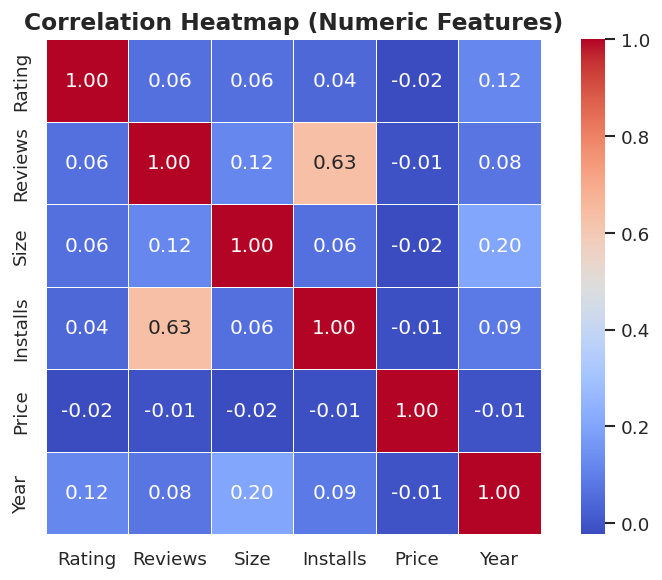

In [58]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlationPlaystore, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - A **Correlation Heatmap** is used when we want to understand the relationship between multiple numerical variables at the same time.
---
2. **What are the insight(s) found from the chart?**
  -  Reviews and Installs show a strong positive correlation (~0.63)
  - Rating has very weak correlation with installs and reviews
  - Size has a weak relationship with installs and reviews
  - Price has almost zero or slightly negative correlation with other features
  - Year shows slight positive relation with Size and Reviews
---
3. **Will the gained insights help creating a positive business impact?**
  - These insights can help businesses and developers focus on the factors that actually influence app growth and engagement.
---

### 2. Top Category of Apps


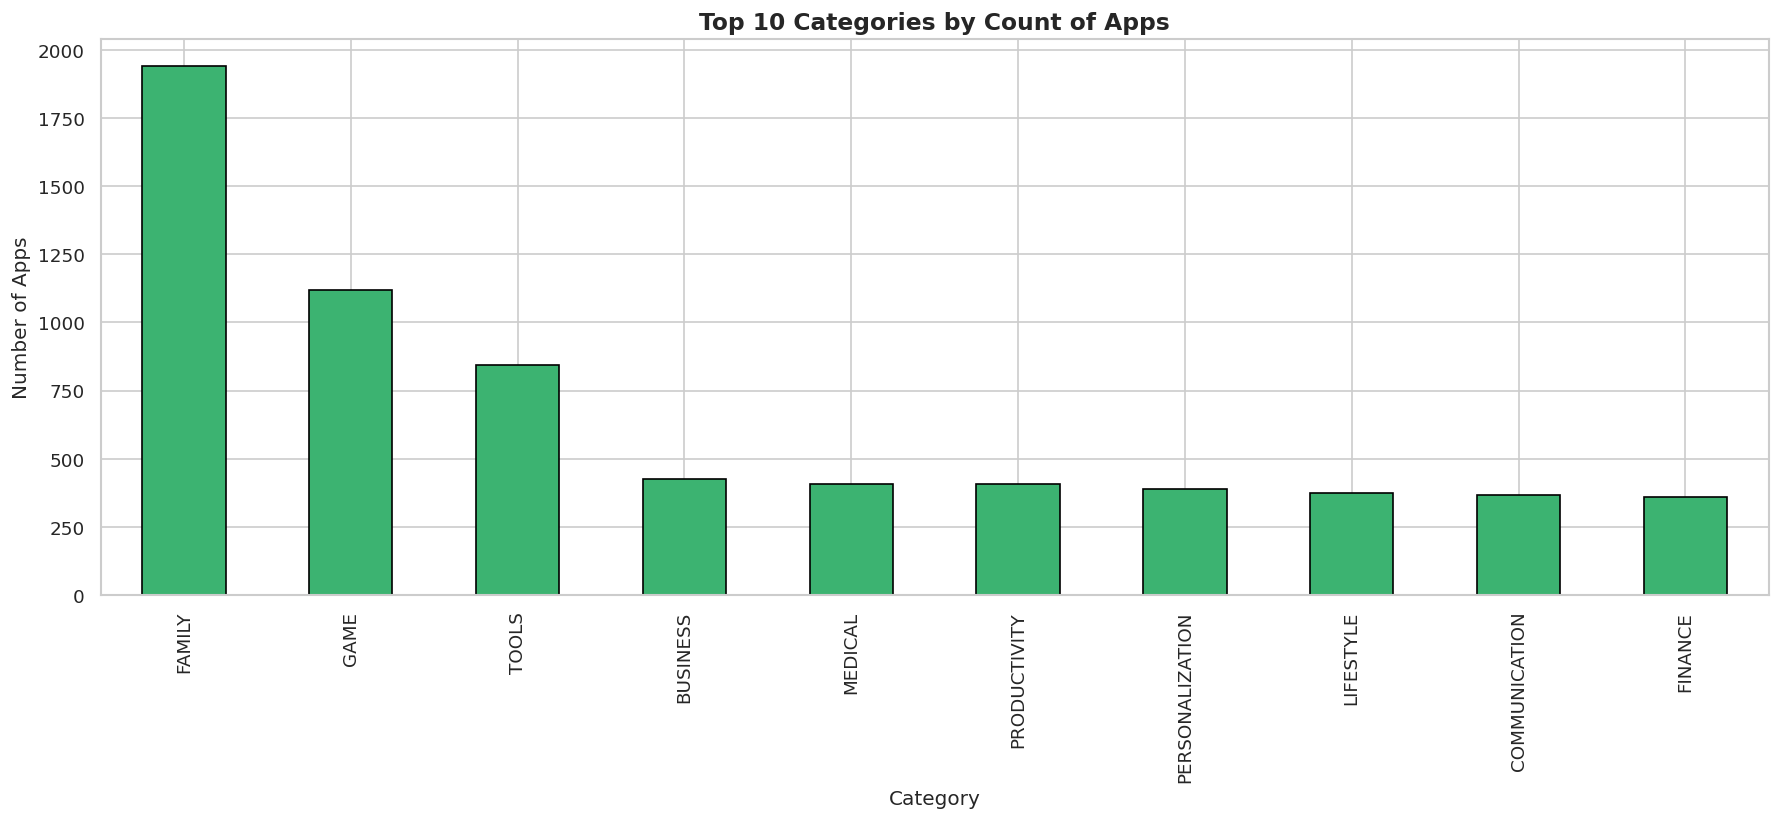

In [59]:
# Top 10 Category Apps by count
plt.figure(figsize=(15, 7))

CategoryCount.head(10).plot(kind="bar", color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Categories by Count of Apps', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - Bar Chart is one of the most effective visualizations for comparing categorical data. The chart clearly shows the number of apps available in each category and helps identify which categories dominate the Google Play Store.
---
2. **What are the insight(s) found from the chart ?**
  - FAMILY category has the highest number of apps in the dataset.
  - GAME and TOOLS categories also contain a large number of applications.
  - Categories like FINANCE, COMMUNICATION, and LIFESTYLE have comparatively fewer apps.
  - The distirbution is highly uneven
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can help businesses and developers identify market competition and opportunities.
---

### 3. Free VS Paid

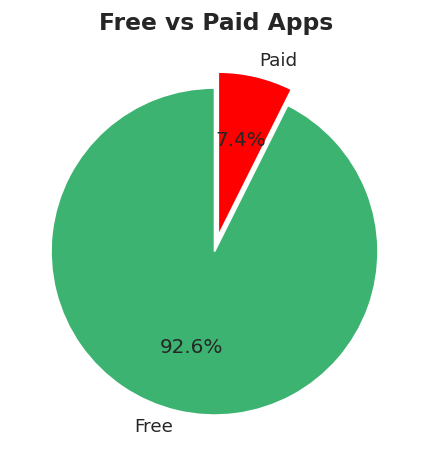

In [60]:
# Free vs Paid apps

plt.figure(figsize=(4, 4))
TypeCount.plot(
    kind='pie',
    autopct="%1.1f%%",
    colors=['mediumseagreen', 'red'],
    startangle=90,
    explode=(0.05, 0.05),
    labels=['Free', 'Paid']
)

plt.title('Free vs Paid Apps', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Pie Chart because it is one of the best visualizations for representing percentage distribution and proportional comparison. Since the analysis only contains two categories - Free and Paid apps, the pie chart clearly shows their contribution to the total app ecosystem.
---
2. **What are the insight(s) found from the chart ?**
  - Approximately 92.6% of apps are Free apps.
  - Only around 7.4% apps are Paid apps.
  - Free apps dominate the Google Play Store ecosystem.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights are highly valuable for business and monetization strategy.
    - users prefer free applications.
    - businesses can adopt freemium models to increase reach and engagement.
---

### 4. Categorywise Install

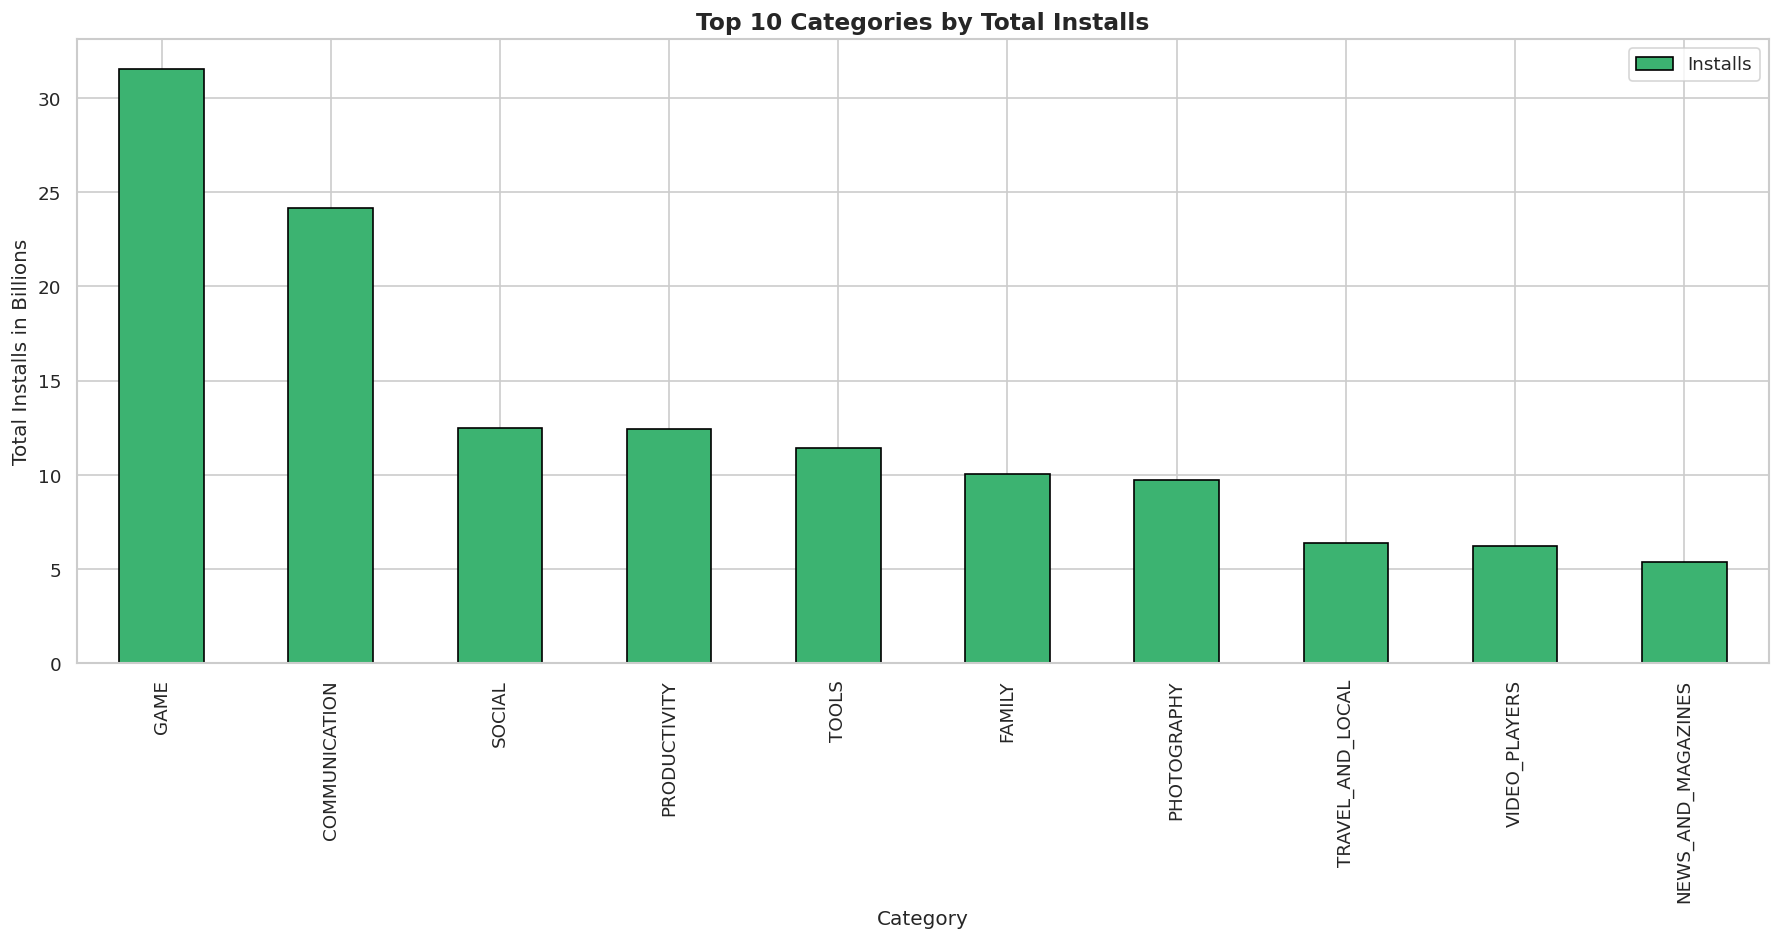

In [61]:
# Top 10 Categories by install

plt.figure(figsize=(15,8))

CategoryInstalls.head(10).plot(kind='bar', x='Category', y='Installs', color='mediumseagreen', edgecolor='black', ax=plt.gca())
plt.title('Top 10 Categories by Total Installs', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Installs in Billions', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Bar Chart because it is highly effective for comparing numerical values across multiple categories. In this analysis, the goal was to compare total installs among different app categories
---
2. **What are the insight(s) found from the chart ?**
  - The GAME category has the highest total installs among all categories.
  - COMMUNICATION apps are the second most installed category.
  - SOCIAL and PRODUCTIVITY apps also have very high install counts.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can strongly support business and development decisions.
    - Company can focus on high-demand categories such as Games, Communication, and Social apps.
    - Investors can choose more engagement applications for profitable results
---

### 5. Distribution of App Ratings

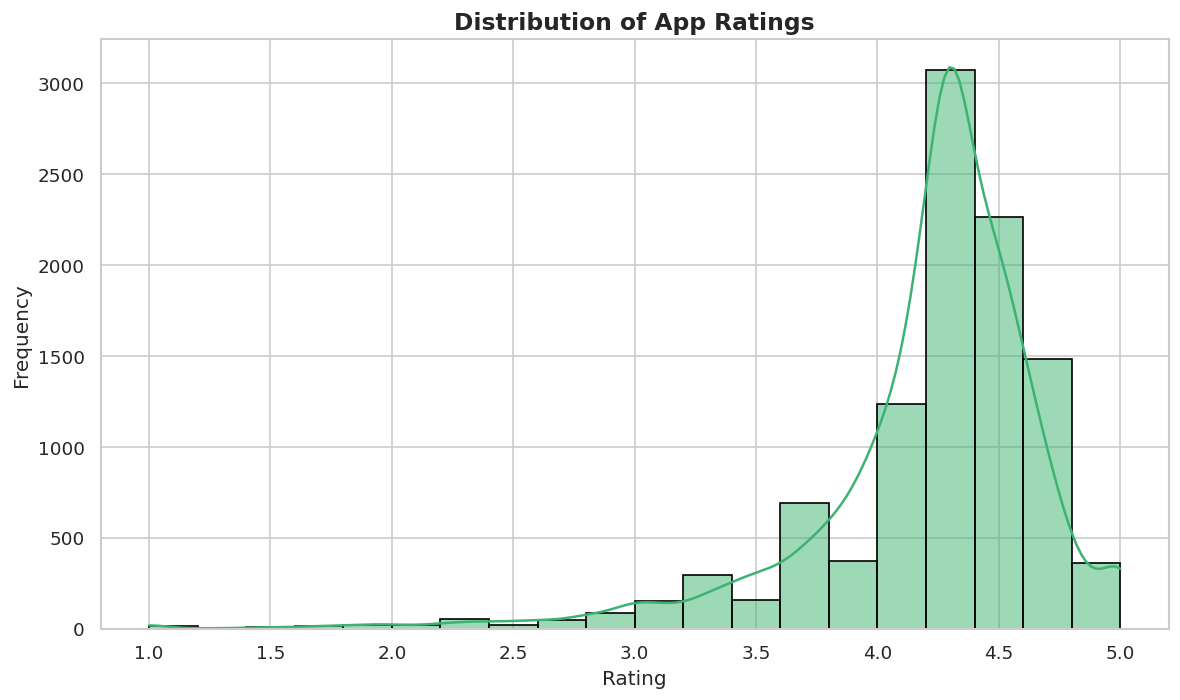

In [62]:
# Distribution of App Ratings
plt.figure(figsize=(10, 6))

sns.histplot(playstore['Rating'], bins=20, kde=True, color ="mediumseagreen", edgecolor="black")

plt.title("Distribution of App Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Histogram with KDE because it is one of the best visualization techniques for analyzing the distribution of continuous numerical data such as app ratings.
---
2. **What are the insight(s) found from the chart ?**
  - Most app ratings are concentrated between 4.0 and 4.5.
  - Very few apps have ratings below 3.0.
  - The distribution is slightly left-skewed, meaning most apps are highly rated.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can help businesses and developers improve product strategy and user satisfaction.

---

### 6. Free vs Paid Rating

/tmp/ipykernel_7413/2543493834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


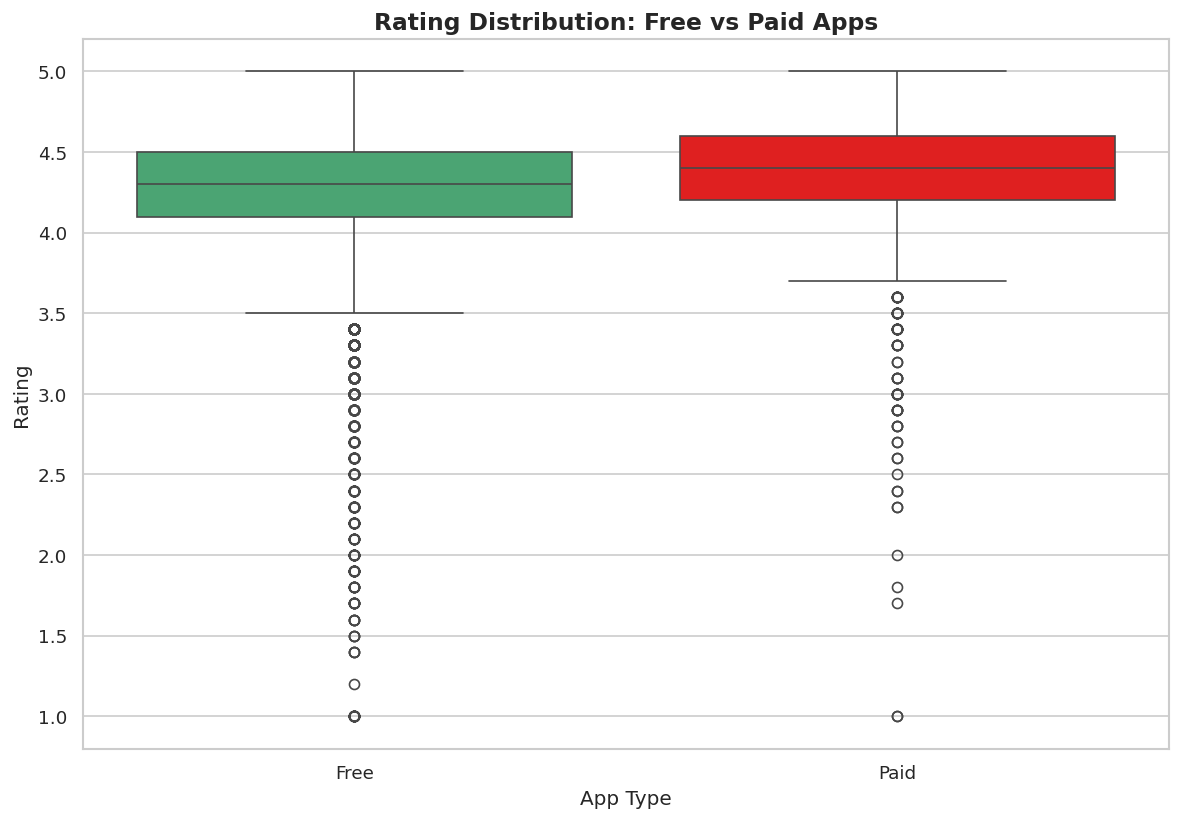

In [63]:
# Free vs Paid Rating

plt.figure(figsize=(10, 7))

sns.boxplot(
    data = playstore,
    x="Type",
    y="Rating",
    palette=["mediumseagreen", "red"]
)

plt.title('Rating Distribution: Free vs Paid Apps', fontsize=14, fontweight='bold')
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()
plt.show()

plt.show()

---
1. **Why we have picked ?**
  - I used a Box Plot because it is highly effective for comparing the distribution of ratings between Free and Paid apps. It displays median values, interquartile ranges, spread, and outliers.
---
2. **What are the insight(s) found from the chart ?**
  - Paid apps have a slightly higher median rating compared to Free apps.
  - Most apps in both categories are rated above 4.0.
  - Free apps show more low-rating outliers than Paid apps.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can support better business and product strategies.
---

### 7. Top 10 Categories by AvgSize

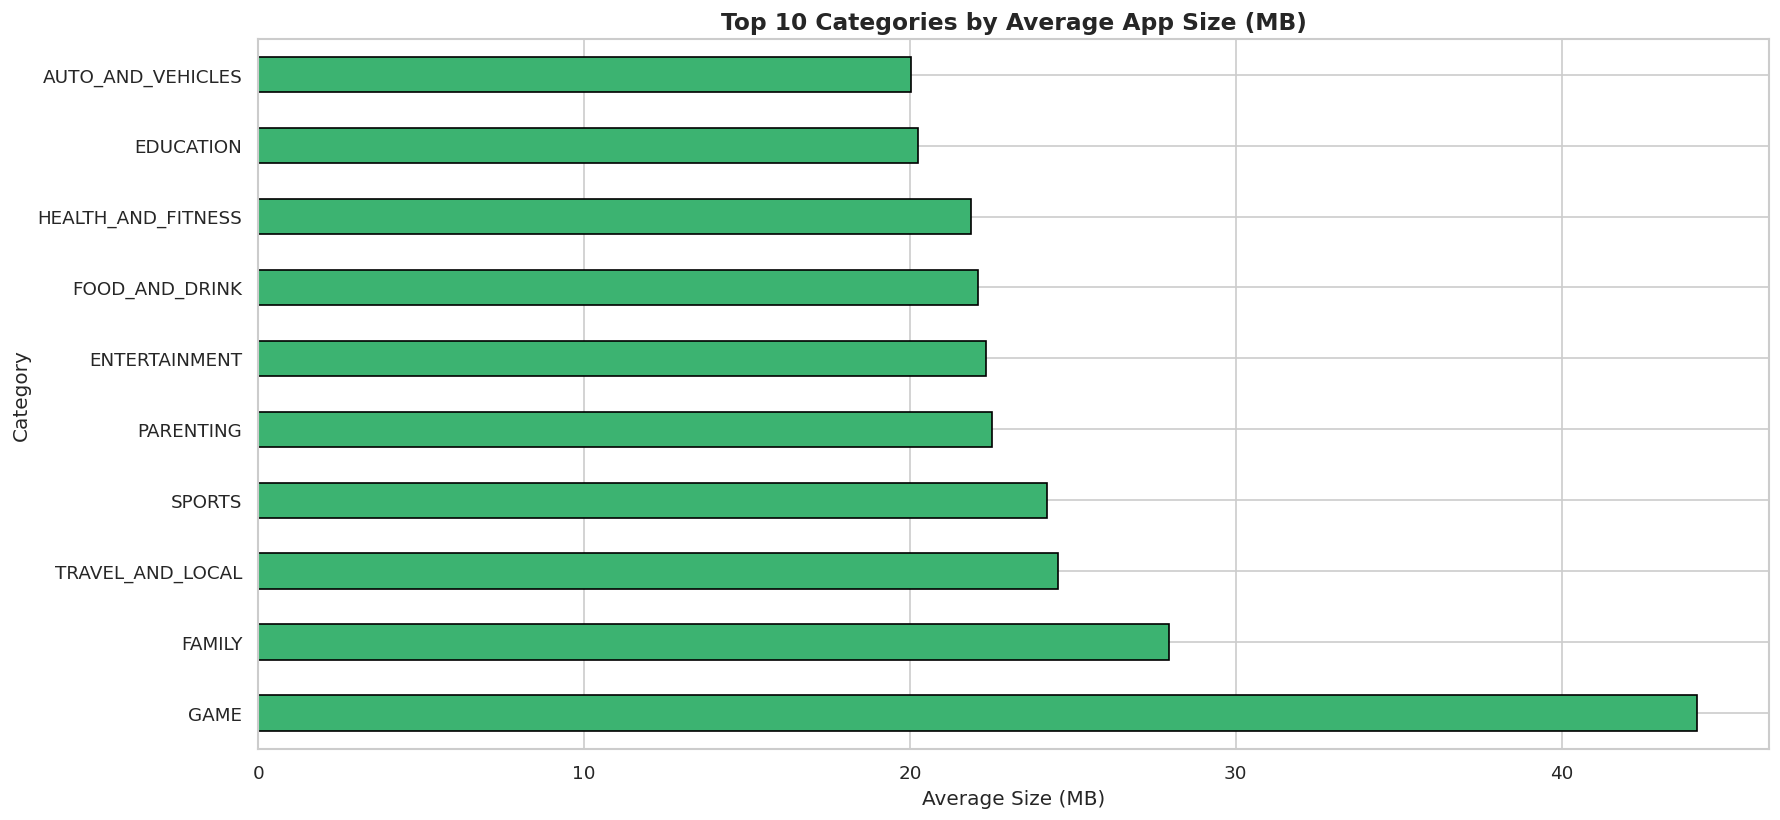

In [64]:
# Top 10 Categories by AvgSize

plt.figure(figsize=(15, 7))

CategorySize.head(10).plot(
    kind="barh",
    color="mediumseagreen",
    edgecolor="black"
)
plt.title('Top 10 Categories by Average App Size (MB)', fontsize=14, fontweight='bold')
plt.xlabel('Average Size (MB)', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Horizontal Bar Chart because it is effective for comparing average values across multiple categories, especially when category names are lengthy.
---
2. **What are the insight(s) found from the chart ?**
  - GAME apps have the highest average app size among all categories.
  - FAMILY apps also occupy relatively large storage sizes.
  - Categories such as SPORTS and TRAVEL_AND_LOCAL have moderately high app sizes.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can help developers and businesses optimize application performance and storage management.
---

### 8. Sentiment Distribution

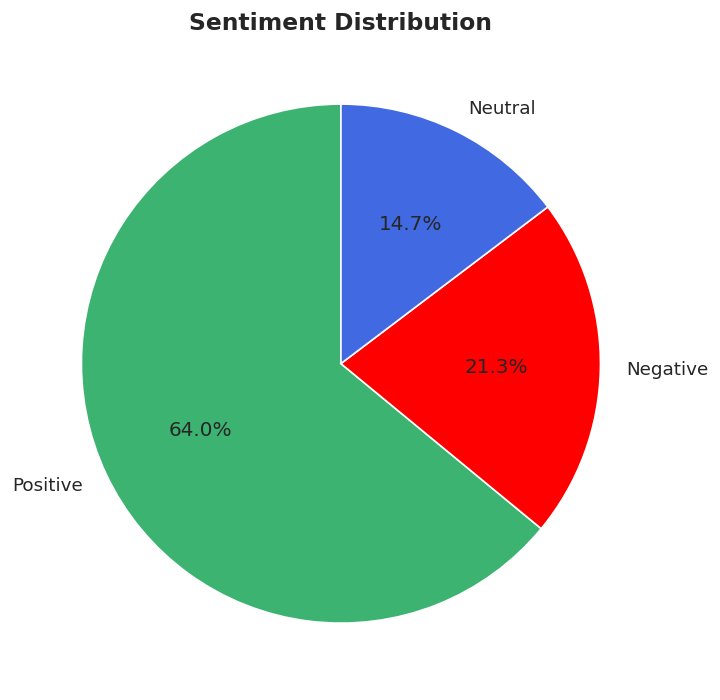

In [65]:
# Sentiment Distribution

plt.figure(figsize=(8, 6))

SentimentCounts.plot(
    kind='pie',
    autopct="%1.1f%%",
    colors=['mediumseagreen', 'red', 'royalblue'],
    startangle=90,
    labels=['Positive', 'Negative', 'Neutral']
)
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Pie Chart because it is highly effective for representing proportional data and percentage distribution among categories.
---
2. **What are the insight(s) found from the chart ?**
  - Positive sentiment dominates the dataset with approximately 64% of total reviews.
  - Negative reviews account for around 21.3% of the reviews.
  - Neutral reviews represent the smallest portion at approximately 14.7%.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can strongly help businesses improve customer satisfaction and decision-making.

---

### 9. Reviews per Year

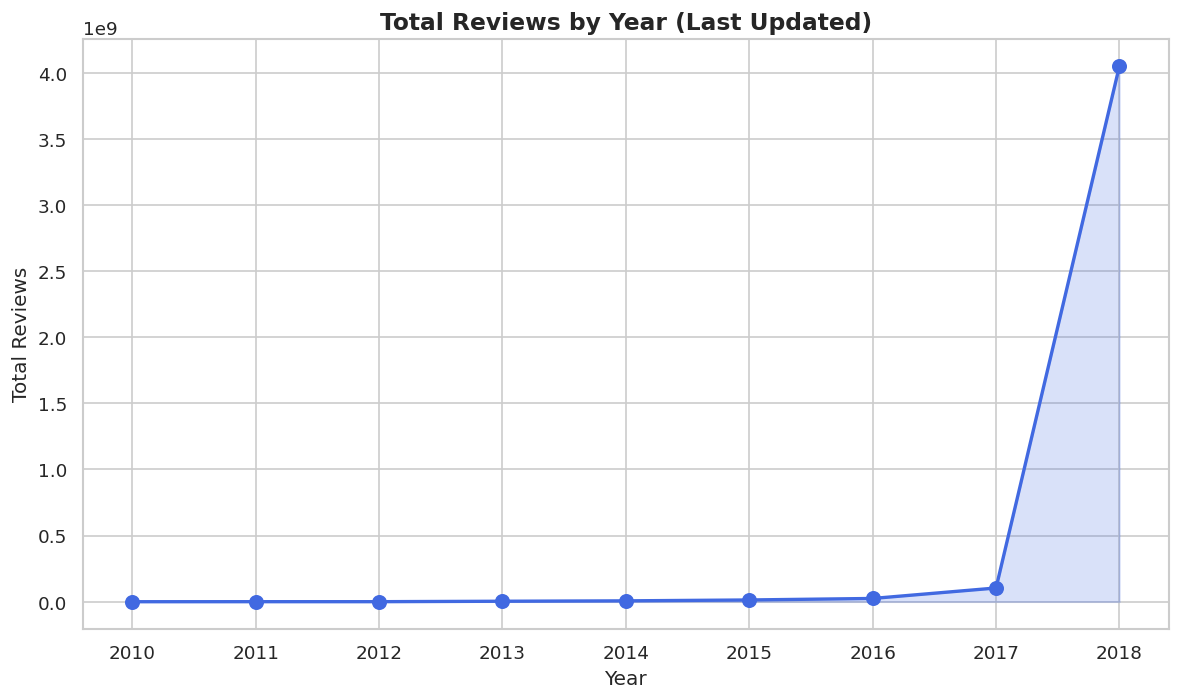

In [66]:
# Total Review by Year
plt.figure(figsize=(10, 6))

plt.plot(
    ReviewYear.index,
    ReviewYear.values,
    marker="o",
    linewidth=2,
    color='royalblue',
    markersize=8
)
plt.fill_between(
    ReviewYear.index,
    ReviewYear.values,
    color='royalblue',
    alpha=0.2
)
plt.title('Total Reviews by Year (Last Updated)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Reviews', fontsize=12)
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Line Chart because it is one of the most effective charts for analyzing trends over time.
---
2. **What are the insight(s) found from the chart ?**
  - Total reviews increased gradually from 2010 to 2016.
  - A significant rise in reviews is visible after 2016.
  - The highest growth occurred in 2018, where reviews increased dramatically.
---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights are valuable for business growth and market strategy.
---

### 10. Top 10 Positive Sentiment per Category

<Figure size 1800x840 with 0 Axes>

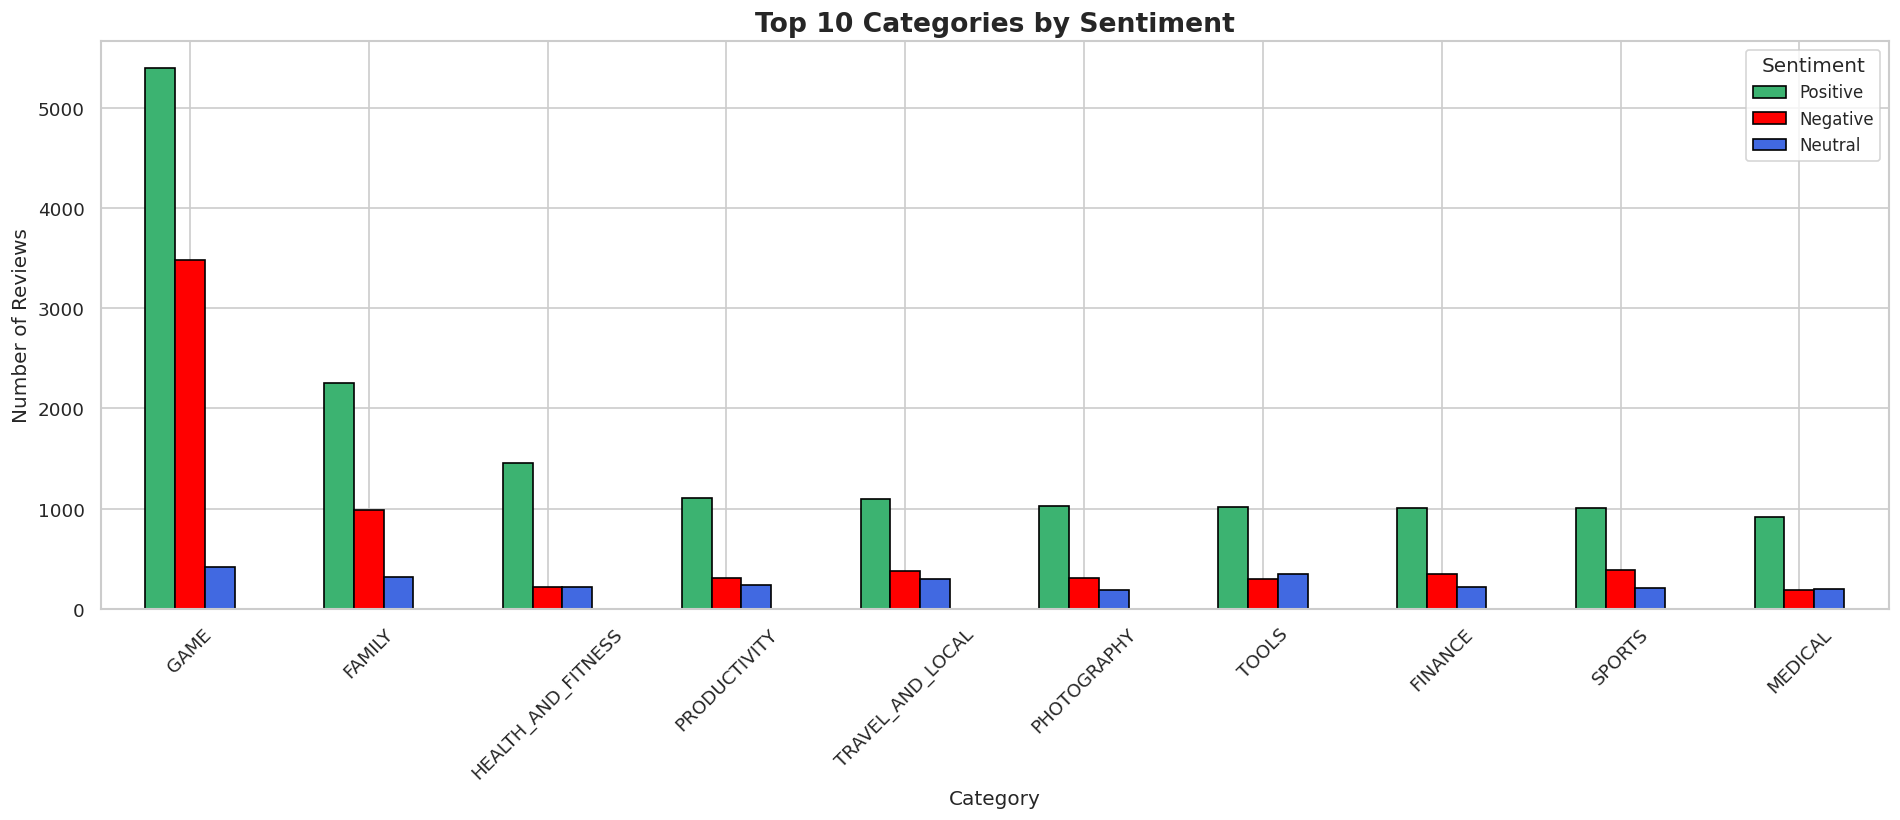

In [67]:
# Top 10 Positive Sentiment per Category

plt.figure(figsize=(15, 7))

CategoryWiseSentiment.head(10).plot(
    kind='bar',
    figsize=(16, 7),
    color=['mediumseagreen', 'red', 'royalblue'],
    edgecolor='black'
)

plt.title('Top 10 Categories by Sentiment', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentiment', fontsize=10)
plt.tight_layout()
plt.show()

---
1. **Why we have picked ?**
  - I used a Grouped Bar Chart because it is highly suitable for comparing multiple sentiment categories across different app categories simultaneously.

---
2. **What are the insight(s) found from the chart ?**
  - GAME apps received the highest number of reviews overall.
  - Positive sentiment dominates across almost all categories.
  - GAME and FAMILY categories have both high positive and high negative reviews, indicating very large user engagement.

---
3. **Will the gained insights help creating a positive business impact ?**
  - These insights can significantly help businesses improve customer satisfaction and strategic planning.

---

## **Phase 6:** Insights

### **1. Based on Visualization**

#### a. Correlation Analysis

- Strong +ve relation between Reviews and Install (More Installs = More Engagement)
- Rating don't dervive popularity strongly
- Size has negligible correlation with installs/reviews
- Price has -ve relation with installs (Price has nothing to do with installs)

#### b. Category Insights

- There is large no. of `Family`, `Games` and `Tools` category application are available at playstore.
- Highest installs come from **Games** and **Communication**
- Some categories have high app count but lower installs

#### c. Free vs Paid Apps

- **~92.6%** apps are Free, only **~7.4%** Paid.
- Free apps dominate both market share and installs.
- Paid apps have *Lower installs* but *Slightly higher median ratings*

#### d. Rating Distribution

- Most apps lie between 4.0 - 4.5 rating range
- Ratings are not a differentiating factor for installs.

#### e. App Size Insights

- Games have highest average size (~40+ MB)
- Utility apps (Education, Auto & Vehicles, etc.) are smaller
- Size does not impact installs or reviews significantly.

#### f. Sentiment Analysis

- **64% Positive**, ~21% Negative, ~15% Neutral.
- Positive sentiment has higher percentage that shows most applications are satisfying.
- Categories like Game & Family generate highest positive reviews.

### **2. Conclusion**

- The success of apps on the Google Play Store is driven by user engagement and category demand rather than technical factors like app size, price, or ratings.

- Free apps dominate the and achieve significantly higher installs compared to paid apps. Categories such as Games and Communication lead in total installs, indicating strong user demand.

- A strong relationship exists between installs and reviews, confirms that popular apps naturally attract more user feedback. Meanwhile, ratings, size, and price show a few influence on app success.

- Sentiment analysis further reveals that most users have a positive experience, successful apps focus on usability and engagement rather than just technical specifications.

## **Final Summary**

- In this project I performed a complete Exploratory Data Analysis (EDA) on Google Play Store data with user reviews.

- Key steps included:
  - Data cleaning (duplicates, missing values)
  - Feature transformation (price in INR, size normalization)
  - Data merging (playstore + user reviews)
  - Visualization-based analysis

- Using multiple visualization techniques such as heatmaps, bar charts, scatter plots, histograms, box plots, and pie charts, meaningful insights were extracted.

- From analysis we get to know that:
  - Installs and reviews are strongly related
  - Free apps dominate the market
  - Category selection plays a crucial role

- Overall, the study shows that app success depends more on accessibility, engagement, and market demand rather than technical attributes.